In [1]:
import torch as th
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torch.utils.data import random_split
from torch.utils.data import TensorDataset

from neuralop.models import GINO

from neuralop import Trainer

In [ ]:
lgino = GINO(
    in_channels=1,
    out_channels=1,
    latent_feature_channels=32,
    # in_gno_channel_mlp_hidden_layers = [64, 64],
)

latent_queries = th.cat(
    (
        th.linspace(-1, 1, 64)[:, None],
        th.linspace(-1, 1, 64)[:, None]
    ),
    dim=1
)
latent_queries.shape

torch.Size([64, 2])

In [65]:
mesh_coordinates = np.load("darcy_flow_training_data/mesh_coordinates.npy")[None, :, :2]
mesh_connectivity = np.load("darcy_flow_training_data/cells.npy")
permeability = np.load("darcy_flow_training_data/permeability.npy")
solution = np.load("darcy_flow_training_data/solution.npy")

mesh_coordinates = th.tensor(mesh_coordinates, dtype=th.float32)
mesh_connectivity = th.tensor(mesh_connectivity, dtype=th.float32)
permeability = th.tensor(permeability, dtype=th.float32)
solution = th.tensor(solution, dtype=th.float32)

dataset = TensorDataset(permeability, solution)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [66]:
mesh_coordinates.shape

torch.Size([1, 4225, 2])

In [67]:
lgino(mesh_coordinates, latent_queries, mesh_coordinates)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (410x256 and 384x64)

In [21]:
mesh_connectivity[:4]

tensor([[0., 1., 2.],
        [0., 3., 2.],
        [4., 0., 3.],
        [3., 2., 5.]])

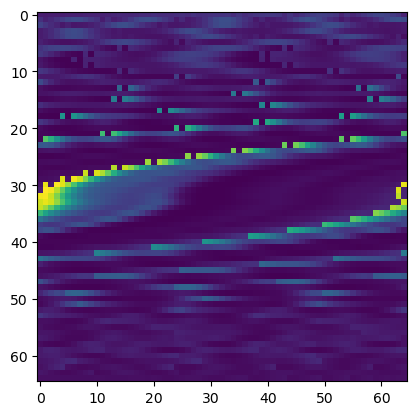

In [30]:
plt.imshow(k0.detach().numpy())